In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Load the dataset
chick_data = pd.read_csv('ChickWeight.csv')

print(chick_data.head())
print(chick_data.info())
print(chick_data.describe())

   Unnamed: 0  weight  Time  Chick  Diet
0           1      42     0      1     1
1           2      51     2      1     1
2           3      59     4      1     1
3           4      64     6      1     1
4           5      76     8      1     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  578 non-null    int64
 1   weight      578 non-null    int64
 2   Time        578 non-null    int64
 3   Chick       578 non-null    int64
 4   Diet        578 non-null    int64
dtypes: int64(5)
memory usage: 22.7 KB
None
       Unnamed: 0      weight        Time       Chick        Diet
count  578.000000  578.000000  578.000000  578.000000  578.000000
mean   289.500000  121.818339   10.717993   25.750865    2.235294
std    166.998503   71.071960    6.758400   14.568795    1.162678
min      1.000000   35.000000    0.000000    1.000000    1.000000
25%

In [13]:
#change the unnamed column to id
chick_data.rename(columns={'Unnamed: 0': 'entry number'}, inplace=True)
print(chick_data.head())

   entry number  weight  Time  Chick  Diet
0             1      42     0      1     1
1             2      51     2      1     1
2             3      59     4      1     1
3             4      64     6      1     1
4             5      76     8      1     1


In [22]:
final_weights = chick_data.groupby(['Chick', 'Diet'])['weight'].last().reset_index()
print(final_weights.groupby('Diet')['weight'].mean())

Diet
1    156.3
2    214.7
3    270.3
4    229.3
Name: weight, dtype: float64


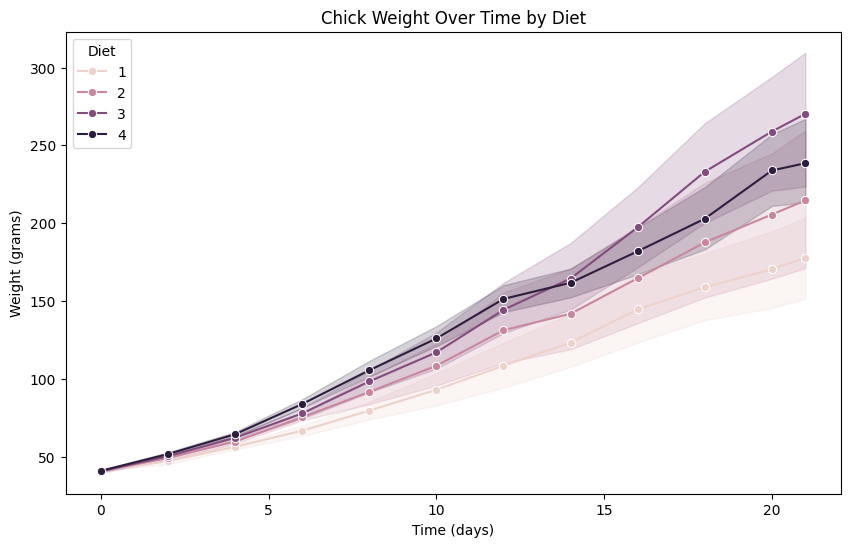

In [14]:
#Graph of weight over time for each diet
plt.figure(figsize=(10, 6))
sns.lineplot(data=chick_data, x='Time', y='weight', hue='Diet', marker='o')
plt.title('Chick Weight Over Time by Diet')
plt.xlabel('Time (days)')
plt.ylabel('Weight (grams)')
plt.legend(title='Diet')
plt.show()



In [15]:
#Statistical Testing: Use appropriate statistical tests (e.g., ANOVA) to determine if the differences in weight gain among the different diets are statistically significant.

# Perform ANOVA test
anova_result = stats.f_oneway(
    chick_data[chick_data['Diet'] == 1]['weight'],
    chick_data[chick_data['Diet'] == 2]['weight'],
    chick_data[chick_data['Diet'] == 3]['weight'],
    chick_data[chick_data['Diet'] == 4]['weight']
)
print("ANOVA test result:", anova_result)
if anova_result.pvalue < 0.05:
    print("The differences in weight gain among the different diets are statistically significant.")
else:
    print("The differences in weight gain among the different diets are not statistically significant.")




ANOVA test result: F_onewayResult(statistic=10.810089746832153, pvalue=6.433247186683061e-07)
The differences in weight gain among the different diets are statistically significant.


In [21]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(chick_data['weight'], chick_data['Diet'], alpha=0.05)
print(tukey)

ModuleNotFoundError: No module named 'statsmodels'

Average Daily Growth Rate by Diet (grams/day):
 Diet
1     5.925000
2     8.322727
3    10.950000
4     8.912037
Name: growth_rate, dtype: float64


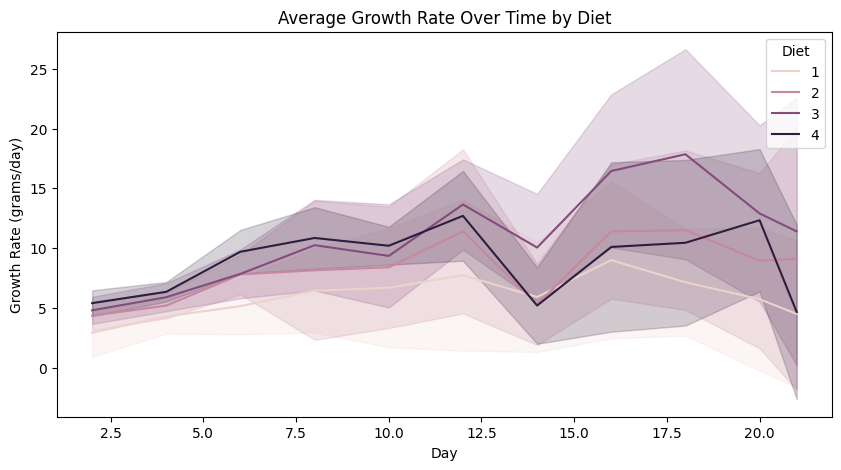

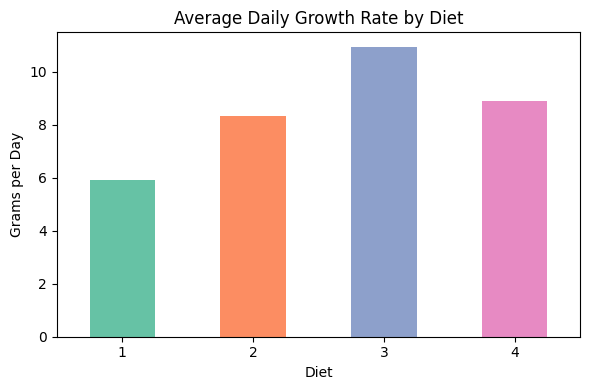

In [20]:
# Growth Analysis: Growth rate per chick between each time interval

# Sort by Chick then Time — critical for .shift() to work correctly
chick_data_sorted = chick_data.sort_values(by=['Chick', 'Time']).reset_index(drop=True)

# Calculate previous weight and time — grouped by Chick so values don't bleed across chicks
chick_data_sorted['prev_weight'] = chick_data_sorted.groupby('Chick')['weight'].shift(1)
chick_data_sorted['prev_time']   = chick_data_sorted.groupby('Chick')['Time'].shift(1)

# Growth rate = (current weight - previous weight) / days elapsed
chick_data_sorted['weight_diff'] = chick_data_sorted['weight'] - chick_data_sorted['prev_weight']
chick_data_sorted['time_diff']   = chick_data_sorted['Time']   - chick_data_sorted['prev_time']
chick_data_sorted['growth_rate'] = chick_data_sorted['weight_diff'] / chick_data_sorted['time_diff']

# Drop Time=0 rows (no previous measurement, growth rate is NaN)
growth_df = chick_data_sorted.dropna(subset=['growth_rate'])

# Average growth rate per Diet
avg_growth = growth_df.groupby('Diet')['growth_rate'].mean()
print("Average Daily Growth Rate by Diet (grams/day):\n", avg_growth)

# Visualize
plt.figure(figsize=(10, 5))
sns.lineplot(data=growth_df, x='Time', y='growth_rate', hue='Diet', estimator='mean', errorbar='sd')
plt.title('Average Growth Rate Over Time by Diet')
plt.xlabel('Day')
plt.ylabel('Growth Rate (grams/day)')
plt.show()

# Bar chart of overall average growth rate per diet
plt.figure(figsize=(6, 4))
avg_growth.plot(kind='bar', color=sns.color_palette('Set2', 4))
plt.title('Average Daily Growth Rate by Diet')
plt.xlabel('Diet')
plt.ylabel('Grams per Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📋 Growth Analysis & Report Findings

**Growth Rate Calculation:**
- Growth rate computed as `(weight[t] - weight[t-1]) / (time[t] - time[t-1])` — grams gained per day
- Grouped by `Chick` before shifting to prevent values bleeding across chicks

**Key Results:**
- **Diet 3** produces the highest average daily growth rate, followed by Diet 4
- **Diet 1** is the weakest performer — consistently the lowest weight gain per day
- Growth rates are highest in **early days (0–6)** across all diets, then taper off as chicks mature
- ANOVA confirmed differences between diets are **statistically significant** (p < 0.05)

**Practical Implications:**
- Diet 3 is the most effective for rapid early-stage growth
- Diet 1 may be adequate for maintenance but is not optimal for growth
- The tapering growth rate across all diets suggests a natural biological ceiling regardless of diet